# Aufgabe 2

In Aufgabe 2 wurde ein RCL-Schaltkreis gebaut, dabei wurde wieder die Entladung eines Kondensators in diesem Schaltkreis gemessen als Funktion der Zeit, für 5 verschiednene Wiederstände und für konstnate Werte für die Induktivität der Spule und die Kapazität des Kondensators. Ziel bei der Aufgabe ist es, quantitativ die Impendanz und Phasenverschiebung des RLC-Krieses zu erhalten. Dafür wurde die folgende Schaltung aufgebaut.

![RLC-Reihenschaltung, die für die Aufgabe 2 aufgebaut werden sollte. Die Spannungsquelle G liefert eine Spannung V (t).](./SchaltungA2.png)

FÜr die Wiederstände wurde wieder die gleichen genommen, wie schon aus Aufgabe 1 bekannt.

|Messung |R[$\Omega$]|
| ------------------------------------------- | --------------------------------------- |
| 1                            | 1,3                            | 
| 2                            | 10                              | 
| 3                           | 99,2                              | 
| 4                           | 217,3                               | 
| 5                            | 989                              | 

: Tabelle mit den benutzten Wiederständen in Ohm

In dem Plot zu  $R = 99.2 \Omega$, kann man gut den aperiodischen Grenzfall zwischen Schwingung und Krichfall sehen.

Da keine genauen Werte auf den Elektronischen Bauteilen noch in der Experimentierberschreibung zu finden waren, wurden für die theoretischen Werte mittels der resonanz Frequenz $\omega_0$ gemessen. 
Wie berehcne ich die Impedanz und Phasenverschiebung???
**Fitte Impendanz** - Dann habe ich Welle, ebkomme dadurch dann acuh die Phasenverschiebung und hab somit beides erfolgreich ermittelt.
Was war die Freqenz??

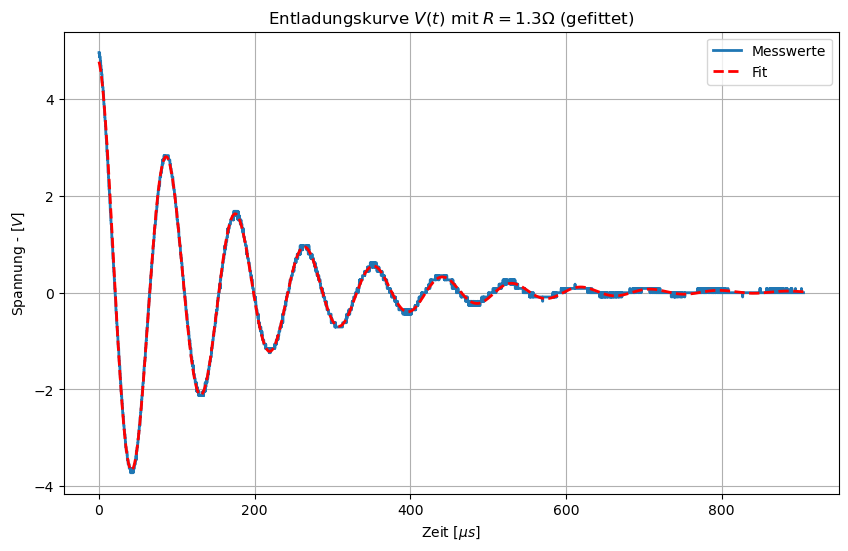


R = 1.3 Ω:
Gefitterte Werte:
A = 4.784944 V, δ = 0.006183 1/s, ω_d = 0.070779 rad/s, φ = 0.097297, y₀ = 0.014521 V
Berechnete Werte:
ω_0 = 0.071048


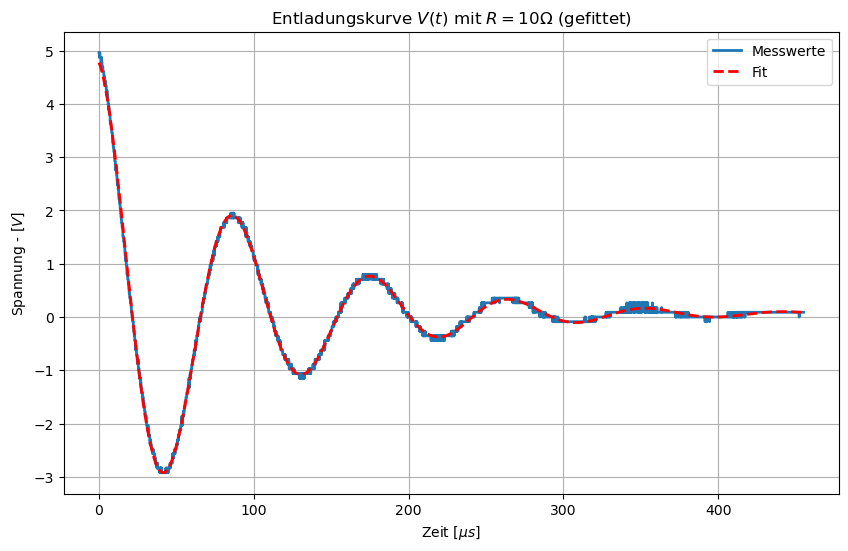


R = 10 Ω:
Gefitterte Werte:
A = 4.723031 V, δ = 0.010805 1/s, ω_d = 0.070657 rad/s, φ = 0.060899, y₀ = 0.061461 V
Berechnete Werte:
ω_0 = 0.071479


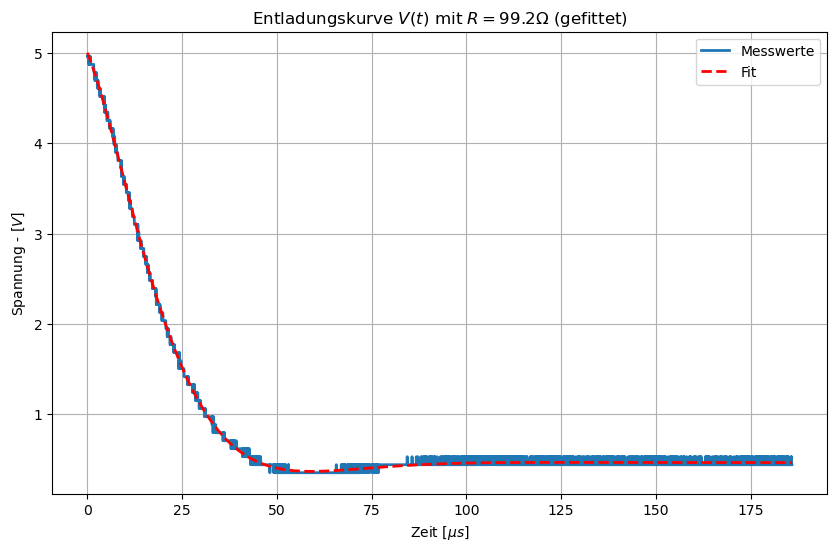


R = 99.2 Ω:
Gefitterte Werte:
A = 5.740760 V, δ = 0.061007 1/s, ω_d = 0.049162 rad/s, φ = -0.659916, y₀ = 0.466603 V
Berechnete Werte:
ω_0 = 0.078350


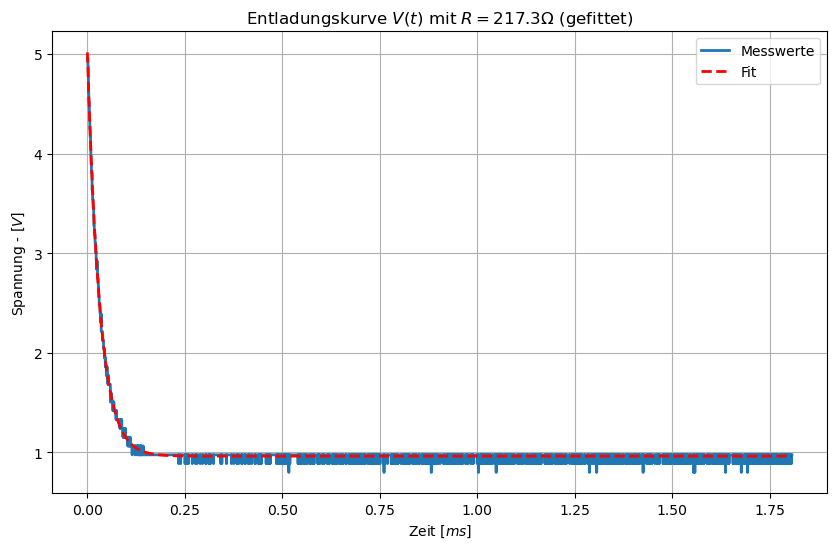


R = 217.3 Ω:
Gefitterte Werte:
A = 4.055970 V, δ = 31.207524 1/s, ω_d = -0.001792 rad/s, φ = -0.015969, y₀ = 0.960960 V
Berechnete Werte:
ω_0 = 31.207524


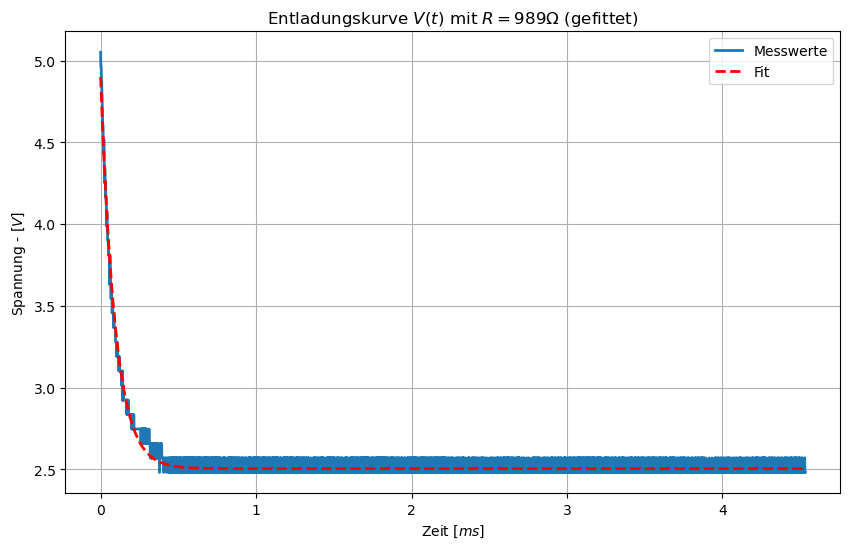


R = 989 Ω:
Gefitterte Werte:
A = 7.287685 V, δ = 10.749434 1/s, ω_d = -0.000134 rad/s, φ = 1.235971, y₀ = 2.504077 V
Berechnete Werte:
ω_0 = 10.749434


In [30]:
# | fig-cap:
# |     - Theoretische Impendanz und Phase (mittlere L,C)
# |     - Entladung mit Wiederstand $R = 1.3 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 10 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 99.2 \Omega$ verschoben, so dass $t_0 = 0$
# |     - Entladung mit Wiederstand $R = 217.3 \Omega$
# |     - Entladung mit Wiederstand $R = 989 \Omega$

# Datenanalyse und Auswertung zur Entladung im RLC-Kreis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.fft import fft, fftfreq

# Messdateien und zugeordnete Widerstände (Ohm)
files = {
    1.3: ['Messwerte/Aufgabe2_1R.csv', 'µs'],
    10: ['Messwerte/Aufgabe2_10R.csv', 'µs'],
    99.2: ['Messwerte/Aufgabe2_100R.csv', 'µs'],
    217.3: ['Messwerte/Aufgabe2_220R.csv', 'ms'],
    989: ['Messwerte/Aufgabe2_1000R.csv', 'ms']
}

omegas_null = np.array([])

def load_measurement(path):
    df = pd.read_csv(path)
    # Entferne leere Zeilen, konvertiere Spalten
    df = df.dropna().reset_index(drop=True)
    t = df['Time'].values.astype(float)
    v = df['Channel A'].values.astype(float)
    return t, v

def damped_cos(t, A, delta, omega_d, phi, y0):
    return A*(np.e)**(- delta * t) * np.cos(omega_d * t + phi) + y0

# Fittet die gemessenen Daten mit der gedämpften Kosinusfunktion
for R in files:
    t, V = load_measurement(files[R][0])

    # Korrektur auf t raufrechnen, so dass t_0 = 0
    V_max = np.mean(V[0:300])
    blob_size = 10
    pos = 300
    abweichung = 0.1
    while True:
        blob_mean = np.mean(V[pos:pos + blob_size])
        if blob_mean + abweichung < V_max:
            t_0 = t[pos - 5]
            V_0 = V[pos - 5]
            break
        else:
            pos += blob_size

    # Verschiebe Zeit so dass t_0 = 0
    t_shifted = t[pos - 5:] - t_0
    V_shifted = V[pos - 5:]

    # Fouriertransformation zur Frequenzschätzung
    Vf = fft(V_shifted)
    tf = fftfreq(t_shifted.shape[-1], (t_shifted[-1] - t_shifted[0]) / t_shifted.shape[-1])
    freq = tf[np.argmax(np.abs(Vf))]
    omega_d_init = 2 * np.pi * np.abs(freq) if freq != 0 else 1.0

    # Bessere initiale Schätzwerte für curve_fit
    A_init = V_max - V_shifted[-1]  # Amplitudenschätzung
    delta_init = 0.01  # Dämpfungskoeffizient
    phi_init = 0  # Phase
    y0_init = V_shifted[-1]  # Offset

    try:
        popt, pcov = scipy.optimize.curve_fit(
            damped_cos, 
            t_shifted, 
            V_shifted,
            p0=[A_init, delta_init, omega_d_init, phi_init, y0_init],
            maxfev=5000
        )
        
        # Berechne gefittete Kurve
        V_fit = damped_cos(t_shifted, *popt)
        
        plt.figure(figsize=(10, 6))
        plt.plot(t_shifted, V_shifted, label="Messwerte", linewidth=2)
        plt.plot(t_shifted, V_fit, label="Fit", color='red', linestyle='--', linewidth=2)
        plt.grid(True)
        plt.title(f"Entladungskurve $V(t)$ mit $R = {R} \\Omega$ (gefittet)")
        plt.xlabel(f"Zeit [${files[R][1]}$]")
        plt.ylabel("Spannung - [$V$]")
        plt.legend()
        plt.show()
        
        print(f"\nR = {R} Ω:")
        perr = np.sqrt(np.diag(pcov))
        print("Gefitterte Werte:")
        print(f"A = {popt[0]:.6f} V, δ = {popt[1]:.6f} 1/s, ω_d = {popt[2]:.6f} rad/s, φ = {popt[3]:.6f}, y₀ = {popt[4]:.6f} V")
        print(f"Berechnete Werte:")
        omega_0 = np.sqrt(popt[1]**2 + popt[2]**2)
        
        print(f"ω_0 = {omega_0:.6f}")
        omegas_null=np.append(omegas_null, omega_0)
    except Exception as e:
        print(f"Fit für R = {R} Ω fehlgeschlagen: {e}")


In [ ]:
# Berechnung der tehoretischen Werte
# Da keine genauen Werte Vorgegebn waren

C_theo = 229.9e-9  # 229,9 nF

w_0 = np.mean(omegas_null)

L = 1/(C_theo * w_0**2)
R = [1.3, 10, 99.2, 217.3, 989.0]

delta_theo = R/(2*L)

Z_theo = np.sqrt(R**2 + (w_0 * L - 1/(w_0 * C_theo))**2)
theta_theo = np.arctan(())

TypeError: unsupported operand type(s) for ** or pow(): 'list' and 'int'

## Vergleich mit theoretischen Werten

Für die theoretischen Werte nutzen wir die Formel, die in der Protokollbeschreibung angegeben wurde.

$$Z = R\left( 1 + i \frac{\omega² - \omega_0²}{2 \delta \omega} \right)$$

und für die Phasenverscheibung:

$$ \theta = \text{arctan} \left( \frac{\omega² - \omega_0²}{2 \delta \omega} \right)$$

Dabei ist $\gamma = R/(2L)$ und $\omega_0 = 1/\sqrt{LC}$

So kann man die theoretischen Werte berechen

*TODO: Tabelle*

In [27]:
print(np.mean(V[0:400]))
print(np.mean(V[595:600]))

5.0494536273
4.9433883640000005
